In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
# ways to load a cvs file

# pd.read_csv('data/example.csv')
# pd.read_csv('https://query1.finance.yahoo.com/v7/finance/download/...'

In [75]:
import yfinance as yf
rets = yf.download(tickers='SPY',
                   interval='1mo',
                   period='max',
                   auto_adjust=True)["Close"]


[*********************100%***********************]  1 of 1 completed


In [76]:
type(rets) # 1 dimensional pd.Series for single stock
rets

Ticker,SPY
Date,
1993-01-01,24.175371
1993-02-01,24.433298
1993-03-01,24.863163
1993-04-01,24.341387
1993-05-01,24.997864
...,...
2026-01-01,690.085327
2026-02-01,684.121643
2026-03-01,648.568787


In [77]:
rets = yf.download(tickers=['SPY', "BND"],
                   interval='1mo',
                   period='max',
                   auto_adjust=True)['Close']
rets # 2 dimensional pd.DataFrame for multiple stocks

[*********************100%***********************]  2 of 2 completed


Ticker,BND,SPY
Date,,
1993-01-01,NaN,24.175383
1993-02-01,NaN,24.433294
1993-03-01,NaN,24.863159
1993-04-01,NaN,24.341385
1993-05-01,NaN,24.997852
...,...,...
2026-01-01,73.268158,690.085327
2026-02-01,74.195976,684.121643
2026-03-01,72.926491,648.568787


In [78]:
rets.dropna(inplace=True)
rets

Ticker,BND,SPY
Date,,
2007-04-01,41.498089,104.388702
2007-05-01,41.102299,107.929581
2007-06-01,40.901752,105.895164
2007-07-01,41.292057,103.021675
2007-08-01,41.865360,104.343735
...,...,...
2026-01-01,73.268158,690.085327
2026-02-01,74.195976,684.121643
2026-03-01,72.926491,648.568787


Text(0.5, 1.0, 'SPY vs BND')

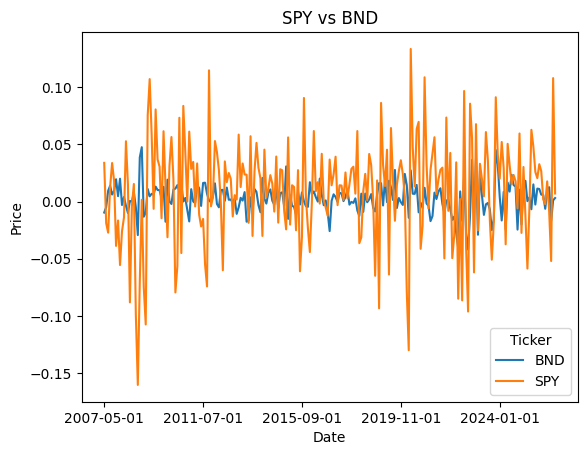

In [101]:
rets.index = rets.index.astype(str)
rets.plot()
plt.ylabel("Price")
plt.title("SPY vs BND") # covert index date to yyyy-mm format


<Axes: xlabel='Date'>

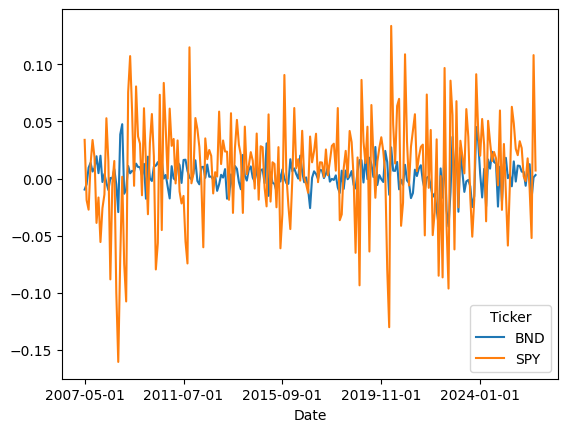

In [80]:
# convert prices to returns; is now a return series
rets = rets.pct_change().dropna()
rets.plot()


In [83]:
compound_returns = (rets + 1).prod() - 1
(compound_returns * 100).round(2).astype('str') + "%"

Ticker
BND     76.49%
SPY    593.34%
dtype: str

In [84]:
rets.head()

Ticker,BND,SPY
Date,,
2007-05-01,-0.009538,0.033920
2007-06-01,-0.004879,-0.018849
2007-07-01,0.009542,-0.027135
2007-08-01,0.013884,0.012833
2007-09-01,0.006212,0.033809


In [85]:
rets.tail()

Ticker,BND,SPY
Date,,
2026-01-01,0.008729,0.017736
2026-02-01,0.012663,-0.008642
2026-03-01,-0.017110,-0.051969
2026-04-01,0.001135,0.108071
2026-05-01,0.003160,0.007111


In [88]:
rets.size

458

In [89]:
rets.shape

(229, 2)

In [90]:
rets.index

Index(['2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01', '2007-09-01',
       '2007-10-01', '2007-11-01', '2007-12-01', '2008-01-01', '2008-02-01',
       ...
       '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
       '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01'],
      dtype='str', name='Date', length=229)

In [93]:
rets.columns

Index(['BND', 'SPY'], dtype='str', name='Ticker')

In [ ]:
# index into a single column getting a series; this case is a stock
rets['SPY'] 

Date
2007-05-01    0.033920
2007-06-01   -0.018849
2007-07-01   -0.027135
2007-08-01    0.012833
2007-09-01    0.033809
                ...   
2026-01-01    0.017736
2026-02-01   -0.008642
2026-03-01   -0.051969
2026-04-01    0.108071
2026-05-01    0.007111
Name: SPY, Length: 229, dtype: float64

In [95]:
# index any number of columns getting a dataframe
rets[['SPY']]

Ticker,SPY
Date,
2007-05-01,0.033920
2007-06-01,-0.018849
2007-07-01,-0.027135
2007-08-01,0.012833
2007-09-01,0.033809
...,...
2026-01-01,0.017736
2026-02-01,-0.008642
2026-03-01,-0.051969


In [ ]:
# index across rows
rets.loc['2009-02-01']

Ticker
BND   -0.009570
SPY   -0.107449
Name: 2009-02-01, dtype: float64

In [102]:
#index via integer position
rets.iloc[20]

Ticker
BND   -0.013229
SPY   -0.074663
Name: 2009-01-01, dtype: float64

In [103]:
# works with slicing as well
rets.loc['2009-02-01': '2009-05-01']

Ticker,BND,SPY
Date,,
2009-02-01,-0.009570,-0.107449
2009-03-01,0.011090,0.075612
2009-04-01,0.004644,0.107215
2009-05-01,0.006865,0.058453


In [104]:
rets.iloc[20-24]

Ticker
BND    0.012663
SPY   -0.008642
Name: 2026-02-01, dtype: float64

In [105]:
#measuring volatility via standard deviation
rets.std()

Ticker
BND    0.013413
SPY    0.045520
dtype: float64

In [ ]:
# easy finance way taught at RCNJ
n_periods = rets.shape[0]
compounded_growth = (1+rets).prod()
monthly_ret = compounded_growth**(1/n_periods) - 1
(monthly_ret + 1)**12 - 1

Ticker
BND    0.030217
SPY    0.106795
dtype: float64

In [110]:
# advanced way with short math
def annualize_rets(r, periods_per_year=12):
    n_periods = r.shape[0]
    compounded_growth = (1+r).prod()
    return compounded_growth**(periods_per_year/n_periods) - 1

In [111]:
annualize_rets(rets)

Ticker
BND    0.030217
SPY    0.106795
dtype: float64

In [122]:
# annualized volatility via standard deviation
def annualize_vol(r, periods_per_year=12):
    return r.std() * (periods_per_year**0.5)

In [124]:
# Raw Sharpe Ratio
annualize_rets(rets) / annualize_vol(rets)

Ticker
BND    0.650338
SPY    0.677259
dtype: float64

<Axes: xlabel='Date'>

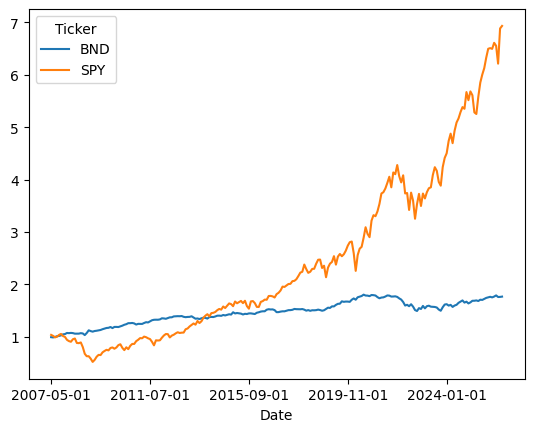

In [143]:
# Wealh Index
wealth_index = (rets+1).cumprod()
wealth_index.plot()

In [152]:
wealth_index = (rets+1).cumprod()




In [153]:
wealth_index.index = pd.to_datetime(wealth_index.index)


In [154]:
start_date = wealth_index.index.min() - pd.DateOffset(months=1)


In [155]:
first_row = pd.DataFrame(data=1, index=[start_date], columns=wealth_index.columns)


In [156]:
wealth_index = pd.concat([first_row, wealth_index])

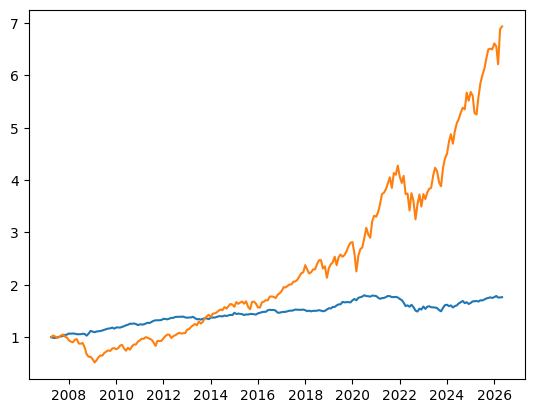

In [157]:
plt.plot(wealth_index)

In [176]:
previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks
max_drawdowns = drawdowns.min()
max_drawdowns_date = drawdowns.idxmin()

In [183]:
plt.annotate(f'Max Drawdown: {max_drawdowns:.2%}', xy=(max_drawdowns_date, max_drawdowns),
            xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdowns * 1.2),
            arrowprops=dict(arrowstyle='->', lw=1), color='blue')

TypeError: unsupported format string passed to Series.__format__

In [185]:
max_drawdown = drawdowns['SPY'].min()
max_drawdown_date = drawdowns['SPY'].idxmin()

plt.annotate(
    f'Max Drawdown: {max_drawdown:.2%}',
    xy=(max_drawdown_date, max_drawdown),
    xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
    arrowprops=dict(arrowstyle='->', lw=1),
    color='blue'
)
plt.plot(wealth_index)

TypeError: can only concatenate str (not "DateOffset") to str

In [186]:
max_drawdown = drawdowns['SPY'].min()
max_drawdown_date = drawdowns['SPY'].idxmin()

plt.annotate(
    f'Max Drawdown: {max_drawdown:.2%}',
    xy=(max_drawdown_date, max_drawdown),
    xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
    arrowprops=dict(arrowstyle='->', lw=1),
    color='blue'
)

TypeError: can only concatenate str (not "DateOffset") to str

In [187]:
wealth_index.index = pd.to_datetime(wealth_index.index)

max_drawdown = drawdowns['SPY'].min()
max_drawdown_date = drawdowns['SPY'].idxmin()

plt.annotate(
    f'Max Drawdown: {max_drawdown:.2%}',
    xy=(max_drawdown_date, max_drawdown),
    xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
    arrowprops=dict(arrowstyle='->', lw=1),
    color='blue'
)

TypeError: can only concatenate str (not "DateOffset") to str

Text(2011-02-01 00:00:00, -0.6094179828918507, 'Max Drawdown: -50.78%')

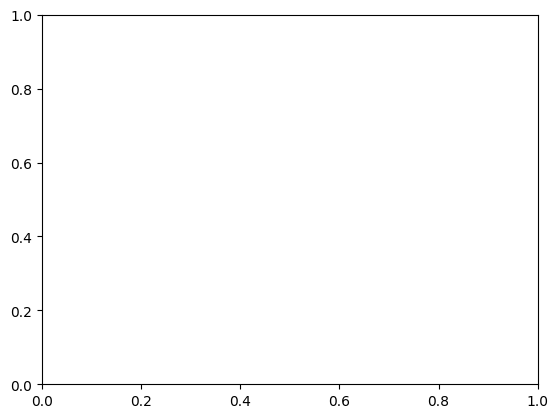

In [188]:
wealth_index.index = pd.to_datetime(wealth_index.index)

previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks

max_drawdown = drawdowns['SPY'].min()
max_drawdown_date = drawdowns['SPY'].idxmin()

plt.annotate(
    f"Max Drawdown: {max_drawdown:.2%}",
    xy=(max_drawdown_date, max_drawdown),
    xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
    arrowprops=dict(arrowstyle="->", lw=1),
    color="blue",
)

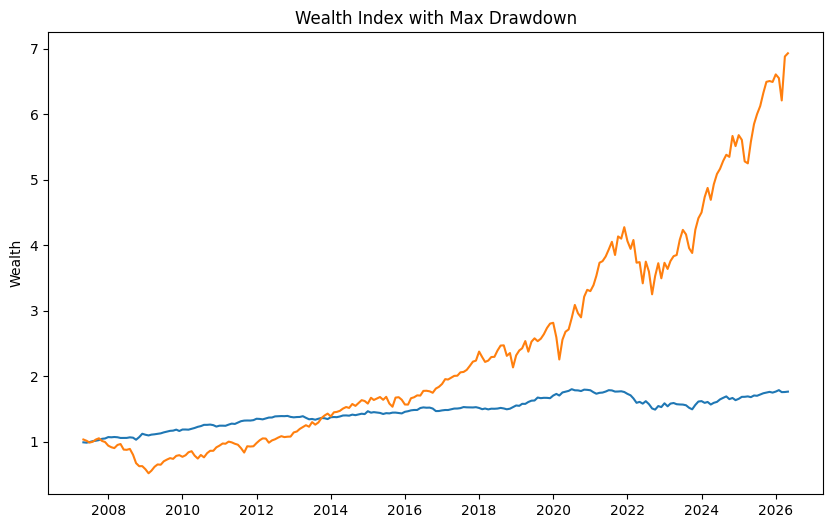

In [189]:
plt.figure(figsize=(10, 6))
plt.plot(wealth_index)
plt.annotate(
    f"Max Drawdown: {max_drawdown:.2%}",
    xy=(max_drawdown_date, max_drawdown),
    xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
    arrowprops=dict(arrowstyle="->", lw=1),
    color="blue",
)
plt.title("Wealth Index with Max Drawdown")
plt.ylabel("Wealth")
plt.show()